<ipython-input-9-a7cb45e9217a>:7: RuntimeWarning: overflow encountered in double_scalars
  return -1000*y + 3000 - 2000*np.exp(-t)
<ipython-input-9-a7cb45e9217a>:18: RuntimeWarning: invalid value encountered in double_scalars
  y_values[i+1] = y_values[i] + h * f(t_values[i], y_values[i])
/opt/conda/lib/python3.8/site-packages/IPython/core/pylabtools.py:128: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


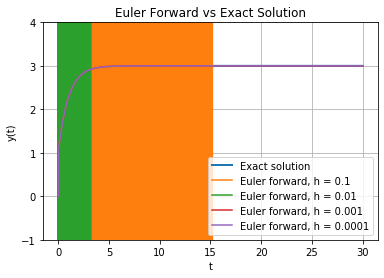

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# ODE: y' = -1000y + 3000 - 2000e^{-t},   y(0)=0

def f(t, y):
    return -1000*y + 3000 - 2000*np.exp(-t)

def y_exact(t):
    return 3 - 0.998*np.exp(-1000*t) - 2.002*np.exp(-t)

def euler_forward(f, t0, y0, t_end, h):
    t_values = np.arange(t0, t_end + h, h)
    y_values = np.zeros(len(t_values))
    y_values[0] = y0

    for i in range(len(t_values) - 1):
        y_values[i+1] = y_values[i] + h * f(t_values[i], y_values[i])

    return t_values, y_values

# Parameters
t0 = 0
t_end = 30
y0 = 0
h_values = [0.1, 0.01, 0.001, 0.0001]

# Exact solution on a fine grid
t_fine = np.linspace(t0, t_end, 100)
y_fine = y_exact(t_fine)

# Plot all Euler runs against exact solution
plt.figure()
plt.plot(t_fine, y_fine, label='Exact solution', linewidth=2)

for h in h_values:
    t_num, y_num = euler_forward(f, t0, y0, t_end, h)
    plt.plot(t_num, y_num, label=f"Euler forward, h = {h}")
 


plt.ylim(-1, 4)
plt.xlabel("t")
plt.ylabel("y(t)")
plt.title("Euler Forward vs Exact Solution")
plt.legend()
plt.grid(True)
plt.show()




AS YOU CAN SEE, if the step size is a slight smidge too big, the solution blows up. I would test for even smaller h values, but I fear that would take forever.